In [7]:
import numpy as np 
import matplotlib.pyplot as plt

In [8]:
def FFT(p):
    p = list(p)
    n = len(p)

    if n & (n - 1) != 0:
        next_pow2 = 2**int(np.ceil(np.log2(n)))
        p = p + [0] * (next_pow2 - n)
        n = next_pow2

    if n == 1:
        return p
    
    w = np.exp((-2j * np.pi )/n)
    Pe, Po, = p[::2], p[1::2]
    ye, yo = FFT(Pe), FFT(Po)
    y = [0] * n

    for i in range(n//2):
        y[i] = ye[i] + w**i * yo[i]
        y[i+n//2] = ye[i] - w**i * yo[i]
        
    return np.array(y)

def IFFT(p):
    p = list(p)
    n = len(p)

    if n & (n - 1) != 0:
        next_pow2 = 2**int(np.ceil(np.log2(n)))
        p = p + [0] * (next_pow2 - n)
        n = next_pow2
        
    if n == 1:
        return p
    
    w = np.exp((2j * np.pi )/n)
    Pe, Po, = p[::2], p[1::2]
    ye, yo = IFFT(Pe), IFFT(Po)
    y = [0] * n

    for i in range(n//2):
        y[i] = (ye[i] + w**i * yo[i]) / 2
        y[i+n//2] = (ye[i] - w**i * yo[i]) / 2

    return np.array(y)

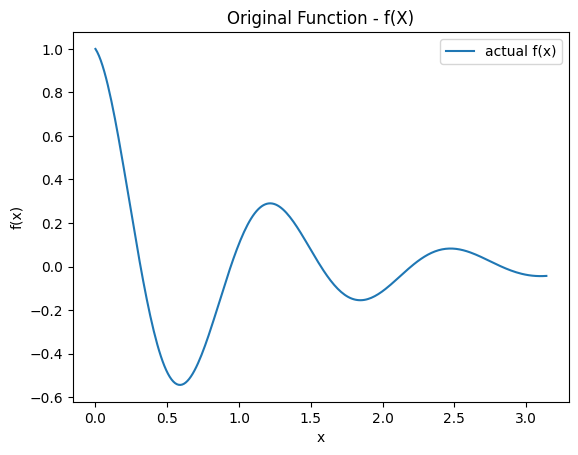

In [9]:
N = 256
x = np.linspace(0, np.pi, N)
f = np.cos(5 * x) * np.exp(-x)
# f = [1, 2, 3, 4, 5, 6, 7, 8]
fk  = FFT(f)

new_f = IFFT(fk)

plt.plot(x, f, "-", label = "actual f(x)")
plt.title("Original Function - f(X)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

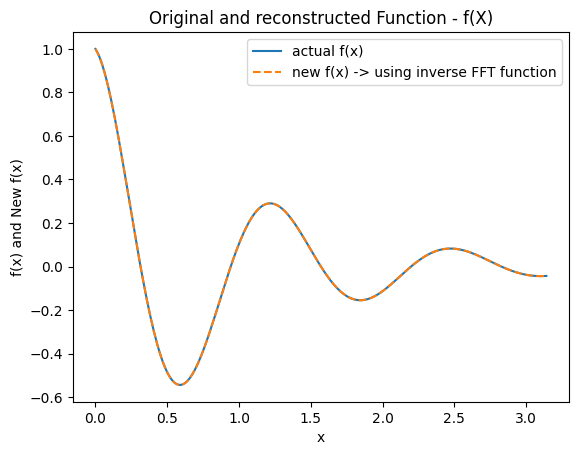

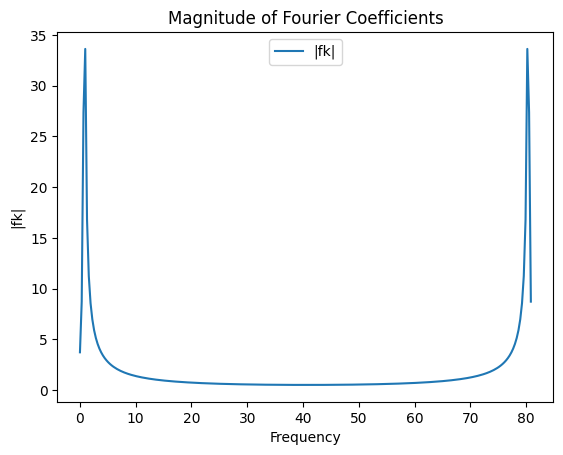

In [10]:
plt.plot(x, f, "-", label = "actual f(x)")
plt.plot(x, new_f, "--", label = "new f(x) -> using inverse FFT function")
plt.title("Original and reconstructed Function - f(X)")
plt.xlabel("x")
plt.ylabel("f(x) and New f(x)")
plt.legend()
plt.show()

dx = x[1] - x[0]
freq = np.arange(N) / (N * dx)

plt.plot(freq, np.abs(fk), label = "|fk|")
plt.title("Magnitude of Fourier Coefficients")
plt.xlabel("Frequency")
plt.ylabel("|fk|")
plt.legend()
plt.show()

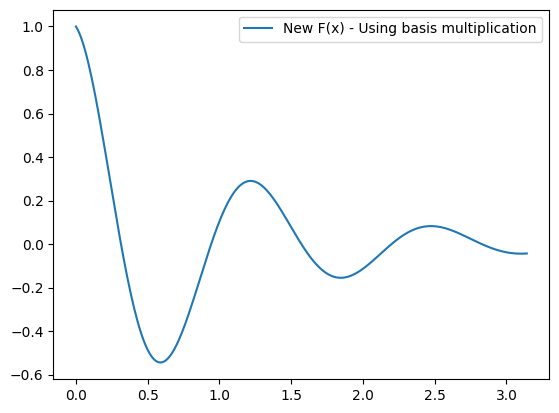

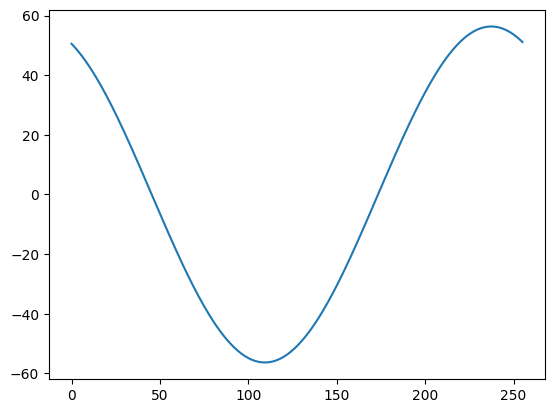

In [ ]:
# reconstructing using basis vector
new_f_ = np.zeros(N, dtype = complex)

for i in range(N):
    b = np.exp(2j * np.pi * i * np.arange(N) / N)
    new_f_ += fk[i] * b
# print(fk)
new_f_ /= N

plt.plot(x, new_f_, label = "New F(x) - Using basis multiplication")
plt.legend()
plt.show()

# plt.plot(range(N), (50.57281531-2.49138964e+01j) *b)

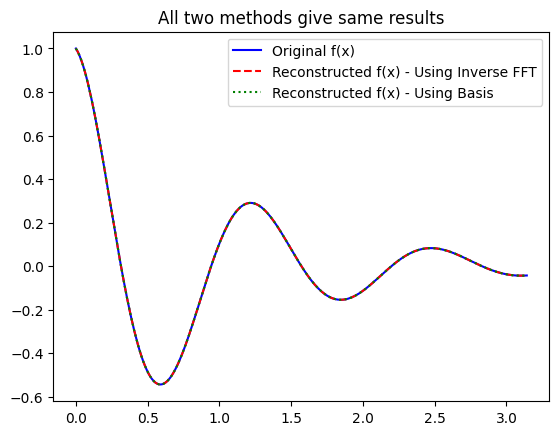

In [ ]:
plt.plot(x, f, 'b-', label="Original f(x)")
plt.title("All two methods give same results")
plt.plot(x, new_f.real, 'r--', label="Reconstructed f(x) - Using Inverse FFT")
plt.plot(x, new_f_.real, 'g:', label="Reconstructed f(x) - Using Basis")
plt.legend()
plt.show()